In [6]:
import healpy as hp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pylab 
import matplotlib as mpl
from math import *
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import Imports_python as imp
import physics_constants as cons
import matplotlib as mpl
mpl.rc('image', cmap='jet')
from crpropa import *
from scipy.fft import fft,fftn,fftfreq
#from colorspacious import cspace_converter
import matplotlib
import os
import sys
import joblib as jb
matplotlib.rcParams.update({'font.size': 25})
from collections import OrderedDict
import palettable as pt
from datetime import date
today = date.today()
import time
today = today.strftime("%b-%d-%Y")
print("today =", today)
from matplotlib.pyplot import figure
deg     =  np.degrees
rad     =  np.radians
log10   =  np.log10
fnan    = float('nan')

today = Apr-02-2026


In [7]:
(200*201*pc)/kpc

40.2

In [32]:
%%time
bTur = 6
randomSeed = 10
vgrid = Grid3f(Vector3d(10*kpc,10*kpc,10*kpc), 201, 100*pc)
lmin = 450*pc
lmax = 4000*pc
initTurbulence(vgrid, bTur*imp.muG, lmin, lmax, -11./3., randomSeed)
bField_old = MagneticFieldGrid(vgrid)
Lc  = turbulentCorrelationLength(lmin/pc, lmax/pc)
print ('Lc = %.1f pc' % turbulentCorrelationLength(lmin/pc, lmax/pc, -11./3.) ) # correlation length
print ('sqrt(<B^2>) = %.1f muG' % (rmsFieldStrength(vgrid) / muG) )  # RMS
print ('<|B|> = %.1f muG' % (meanFieldStrength(vgrid) / muG) ) # mean
print ('B(10 kpc, 0, 0) =', bField_tur.getField(Vector3d(10,0,0) * kpc) / muG, 'muG')
print ('B(20 kpc, 0, 0) =', bField_tur.getField(Vector3d(20,0,0) * kpc) / muG, 'muG')
print ('B(0 kpc, 0, 0) =', bField_tur.getField(Vector3d(0,0,0) * kpc) / muG, 'muG')

2026-04-02 09:52:23 [WARNING] initTurbulence is deprecated and will be removed in the future. Replace it with a more appropriate turbulent field model instance.


Lc = 1015.7 pc
sqrt(<B^2>) = 6.0 muG
<|B|> = 5.5 muG
B(10 kpc, 0, 0) = Vector(-3.62218, -2.20298, -1.57211) muG
B(20 kpc, 0, 0) = Vector(0.67765, -2.83818, 0.409236) muG
B(0 kpc, 0, 0) = Vector(-0.347837, -2.8988, -2.06911) muG
CPU times: user 1.09 s, sys: 88.7 ms, total: 1.18 s
Wall time: 1.18 s


2026-04-02 09:52:24 [WARNING] turbulentCorrelationLength is deprecated and will be removed in the future. Replace it with a more appropriate turbulent field model and call getCorrelationLength().
2026-04-02 09:52:24 [WARNING] turbulentCorrelationLength is deprecated and will be removed in the future. Replace it with a more appropriate turbulent field model and call getCorrelationLength().


In [33]:
randomSeed = 10
bTur = 6
lmin = 450*pc
lmax = 4000*pc
spectrum = SimpleTurbulenceSpectrum(bTur * imp.muG, lmin, lmax, -11./3.)
gridProp = GridProperties(Vector3d(10*kpc, 10*kpc, 10*kpc), 201, 100*pc)

bField_tur = SimpleGridTurbulence(spectrum, gridProp, randomSeed)
Lc = bField_tur.getCorrelationLength()

print ('Lc = %.1f pc' % turbulentCorrelationLength(lmin/pc, lmax/pc, -11./3.) ) # correlation length
print ('sqrt(<B^2>) = %.1f muG' % (rmsFieldStrength(vgrid) / muG) )  # RMS
print ('<|B|> = %.1f muG' % (meanFieldStrength(vgrid) / muG) ) # mean
print ('B(10 kpc, 0, 0) =', bField_tur.getField(Vector3d(10,0,0) * kpc) / muG, 'muG')
print ('B(20 kpc, 0, 0) =', bField_tur.getField(Vector3d(20,0,0) * kpc) / muG, 'muG')
print ('B(0 kpc, 0, 0) =', bField_tur.getField(Vector3d(0,0,0) * kpc) / muG, 'muG')

Lc = 1015.7 pc
sqrt(<B^2>) = 6.0 muG
<|B|> = 5.5 muG
B(10 kpc, 0, 0) = Vector(-3.62218, -2.20298, -1.57211) muG
B(20 kpc, 0, 0) = Vector(0.67765, -2.83818, 0.409236) muG
B(0 kpc, 0, 0) = Vector(-0.347837, -2.8988, -2.06911) muG


2026-04-02 09:52:31 [WARNING] turbulentCorrelationLength is deprecated and will be removed in the future. Replace it with a more appropriate turbulent field model and call getCorrelationLength().


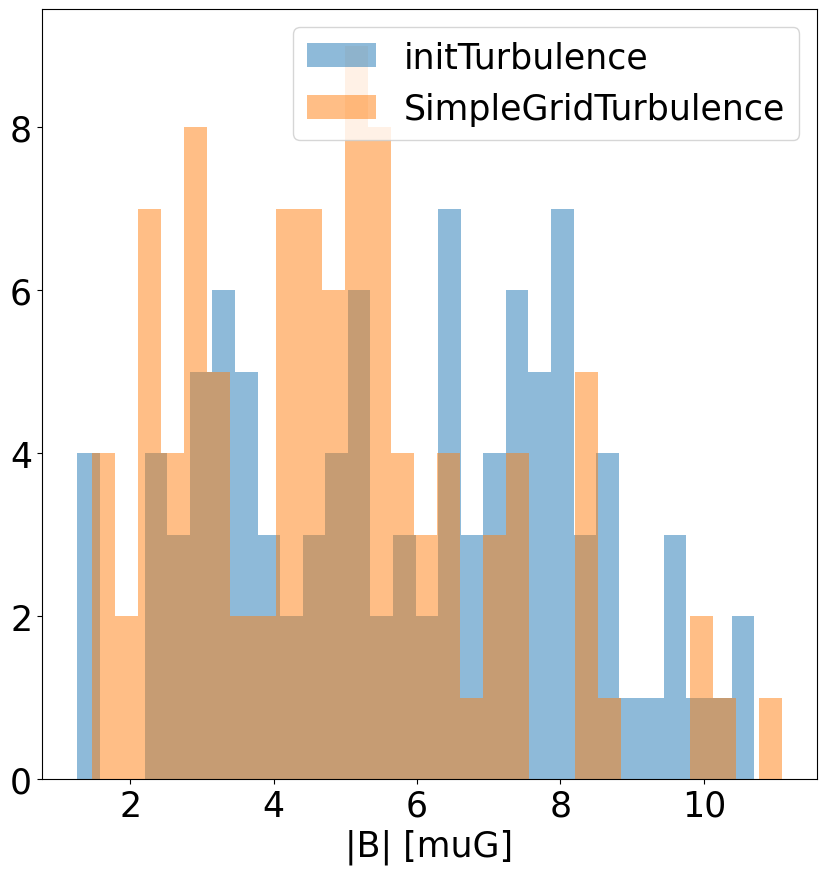

In [36]:
import numpy as np

positions = [Vector3d(x*kpc, 0, 0) for x in np.linspace(-10, 10, 100)]

B_old = [bField_old.getField(p).getR() / muG for p in positions]
B_new = [bField_tur.getField(p).getR() / muG for p in positions]

plt.figure(figsize=(10, 10))
plt.hist(B_old, bins=30, alpha=0.5, label='initTurbulence')
plt.hist(B_new, bins=30, alpha=0.5, label='SimpleGridTurbulence')
plt.xlabel('|B| [muG]')
plt.legend()
plt.show()

# print([x for x in dir(crpropa) if 'urb' in x])

# help(TurbulenceSpectrum)

##
Let's say you have $N$ signals (e.g., lines), and each has a complex Fourier component at some wavenumber $k$:
\[
F_k^{(1)},\ F_k^{(2)},\ \dots,\ F_k^{(N)}
\]

❌ Incorrect Method: Sum of Amplitudes, Then Square
You sum all complex amplitudes:
\begin{equation}
\text{sum\_fft} = \sum_{n=1}^{N} F_k^{(n)}
\end{equation}

Then compute the power as:
\begin{equation}
P_{\text{wrong}}(k) = \left| \text{sum\_fft} \right|^2
\end{equation}

This expands to:
\begin{equation}
P_{\text{wrong}}(k) = \left| \sum_{n=1}^{N} F_k^{(n)} \right|^2 
= \sum_{n=1}^{N} \left| F_k^{(n)} \right|^2 
+ \sum_{n \ne m} F_k^{(n)} \left( F_k^{(m)} \right)^*
\end{equation}

The second term is a \textbf{cross-term} — it depends on the phase relationships between signals. If those phases are not perfectly random, this term can constructively or destructively interfere, which skews the result. Therefore, this method is $\textbf{not statistically valid}$ for estimating the average power spectrum in turbulent or incoherent systems.

✅ Correct Method: Average of Squared Amplitudes

Instead, compute the power for each line (or sample) individually:
\begin{equation}
P_k^{(n)} = \left| F_k^{(n)} \right|^2
\end{equation}

Then average:
\begin{equation}
P_{\text{correct}}(k) = \frac{1}{N} \sum_{n=1}^{N} P_k^{(n)} 
= \frac{1}{N} \sum_{n=1}^{N} \left| F_k^{(n)} \right|^2
\end{equation}

This method reflects the average energy at scale $k$, and is $\textbf{statistically unbiased}$ — it works regardless of the phase relationships between signals.


In [ ]:
%%time
dr = 10*pc

len_x,len_y,len_z = 200,200,200

x = np.linspace(1,1000,len_x)*dr
y = np.linspace(1,1000,len_y)*dr
z = np.linspace(1,1000,len_z)*dr

# x = np.logspace(0,3.,len_x)*dr
# y = np.logspace(0,3.,len_y)*dr
# z = np.logspace(0,3.,len_y)*dr


B_tur = np.zeros([len_x,len_y,len_z,3])

for i in range(0,len_x):
    for j in range(0,len_y):
        for k in range(0,len_z):
        
            pos = Vector3d(x[i],y[j],z[k])
            
            B =  (bField_tur.getField(pos) /imp.gauss) # B in [G]
            
            B_tur[i,j,k,:] = np.array(B)


In [ ]:
import numpy as np
from numpy import pi, cos, sin

def compute_1D_power_spectra(B_tur, x, y, z, lambdas, ind=80):
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]
    
    len_lambda = len(lambdas)
    PS_x = np.zeros((len_lambda, 3))
    PS_y = np.zeros((len_lambda, 3))
    PS_z = np.zeros((len_lambda, 3))
    
    nx, ny, nz, _ = B_tur.shape

    for i, lambda_i in enumerate(lambdas):
        # --- X-direction ---
        arg_x = 2 * pi * x / lambda_i
        cos_x = cos(arg_x)
        sin_x = sin(arg_x)
        powers_x = []
        for o in range(ind):
            if o+2 >= ny or o >= nz:
                continue
            B_line = B_tur[:, o+2, o, :]  # shape (nx, 3)
            real_part = np.sum(B_line * cos_x[:, None] * dx, axis=0)
            imag_part = np.sum(B_line * sin_x[:, None] * dx, axis=0)
            fft_val = real_part - 1j * imag_part
            powers_x.append(np.abs(fft_val)**2)
            # print(B_line.shape,np.array(powers_x).shape, fft_val.shape)
        if powers_x:
            PS_x[i, :] = np.mean(powers_x, axis=0)

        # --- Y-direction ---
        arg_y = 2 * pi * y / lambda_i
        cos_y = cos(arg_y)
        sin_y = sin(arg_y)
        powers_y = []
        for o in range(ind):
            if o+5 >= nz or o >= nx:
                continue
            B_line = B_tur[o, :, o+5, :]
            real_part = np.sum(B_line * cos_y[:, None] * dy, axis=0)
            imag_part = np.sum(B_line * sin_y[:, None] * dy, axis=0)
            fft_val = real_part - 1j * imag_part
            powers_y.append(np.abs(fft_val)**2)
        if powers_y:
            PS_y[i, :] = np.mean(powers_y, axis=0)

        # --- Z-direction ---
        arg_z = 2 * pi * z / lambda_i
        cos_z = cos(arg_z)
        sin_z = sin(arg_z)
        powers_z = []
        for o in range(ind):
            if o+5 >= ny or o >= nx:
                continue
            B_line = B_tur[o, o+5, :, :]
            real_part = np.sum(B_line * cos_z[:, None] * dz, axis=0)
            imag_part = np.sum(B_line * sin_z[:, None] * dz, axis=0)
            fft_val = real_part - 1j * imag_part
            powers_z.append(np.abs(fft_val)**2)
        if powers_z:
            PS_z[i, :] = np.mean(powers_z, axis=0)

    return PS_x, PS_y, PS_z


In [ ]:
bins_per_decade = 300
len_lambda = int(bins_per_decade * (log10(lmax) - log10(lmin)))
lambdas = np.logspace(log10(lmin),log10(lmax),len_lambda)
PS_x, PS_y, PS_z = compute_1D_power_spectra(B_tur, x, y, z, lambdas, ind=80)

# Combine components
PS_x_total = np.sum(PS_x, axis=1)
PS_y_total = np.sum(PS_y, axis=1)
PS_z_total = np.sum(PS_z, axis=1)

# Plot
k_vals = 1 / lambdas

plt.figure(figsize=(10, 10))
# plt.loglog(k_vals, PS_x_total, label='1D PS (x)')
# plt.loglog(k_vals, PS_y_total, label='1D PS (y)')
# plt.loglog(k_vals, PS_z_total, label='1D PS (z)')
plt.loglog(lambdas/pc, PS_x_total, label='1D PS (x)')
plt.loglog(lambdas/pc, PS_y_total, label='1D PS (y)')
plt.loglog(lambdas/pc, PS_z_total, label='1D PS (z)')

# Reference slope line for k^{-5/3}
# k_ref = k_vals[len(k_vals)//3]
# P_ref = PS_x_total[len(k_vals)//3]
# slope_line = P_ref * (k_vals / k_ref)**(5/3)
# plt.loglog(k_vals, slope_line, '--k', label=r'$k^{-5/3}$ reference')

L_ref = lambdas[len(lambdas)//3]
P_ref = PS_x_total[len(lambdas)//3]
slope_line = P_ref * (lambdas / L_ref)**(5/3)
plt.loglog(lambdas/pc, slope_line, '--k', label=r'$L^{5/3}$ reference')

# plt.xlabel(r'$k$ (1/pc)')
plt.xlabel(r'$L$')

plt.ylabel(r'$P(k)$')
plt.title('1D Directional Magnetic Power Spectra')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()


In [ ]:
bins_per_decade = 300
len_lambda = int(bins_per_decade * (log10(lmax) - log10(lmin)))
lambdas = np.logspace(log10(lmin),log10(lmax),len_lambda)
PS_x, PS_y, PS_z = compute_1D_power_spectra(B_tur, x, y, z, lambdas, ind=80)

# Combine components
PS_x_total = np.sum(PS_x, axis=1)
PS_y_total = np.sum(PS_y, axis=1)
PS_z_total = np.sum(PS_z, axis=1)

# Plot
k_vals = 1 / lambdas

plt.figure(figsize=(10, 10))
# plt.loglog(k_vals, PS_x_total, label='1D PS (x)')
# plt.loglog(k_vals, PS_y_total, label='1D PS (y)')
# plt.loglog(k_vals, PS_z_total, label='1D PS (z)')
plt.loglog(lambdas/pc, PS_x_total, label='1D PS (x)')
plt.loglog(lambdas/pc, PS_y_total, label='1D PS (y)')
plt.loglog(lambdas/pc, PS_z_total, label='1D PS (z)')

# Reference slope line for k^{-5/3}
# k_ref = k_vals[len(k_vals)//3]
# P_ref = PS_x_total[len(k_vals)//3]
# slope_line = P_ref * (k_vals / k_ref)**(5/3)
# plt.loglog(k_vals, slope_line, '--k', label=r'$k^{-5/3}$ reference')

L_ref = lambdas[len(lambdas)//3]
P_ref = PS_x_total[len(lambdas)//3]
slope_line = P_ref * (lambdas / L_ref)**(5/3)
plt.loglog(lambdas/pc, slope_line, '--k', label=r'$L^{5/3}$ reference')

# plt.xlabel(r'$k$ (1/pc)')
plt.xlabel(r'$L$')

plt.ylabel(r'$P(k)$')
plt.title('1D Directional Magnetic Power Spectra')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()


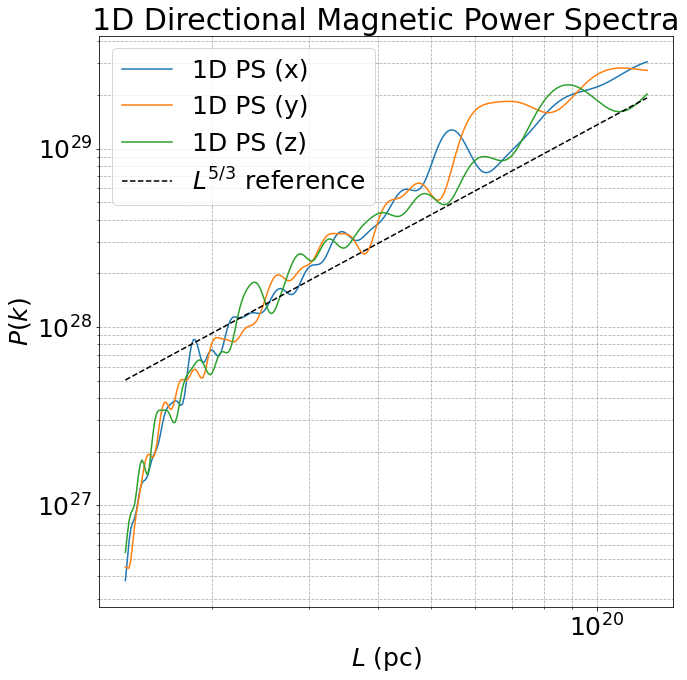

In [8]:
bins_per_decade = 300
len_lambda = int(bins_per_decade * (log10(lmax) - log10(lmin)))
lambdas = np.logspace(log10(lmin),log10(lmax),len_lambda)
PS_x, PS_y, PS_z = compute_1D_power_spectra(B_tur, x, y, z, lambdas, ind=80)

# Combine components
PS_x_total = np.sum(PS_x, axis=1)
PS_y_total = np.sum(PS_y, axis=1)
PS_z_total = np.sum(PS_z, axis=1)

# Plot
k_vals = 1 / lambdas

plt.figure(figsize=(10, 10))
# plt.loglog(k_vals, PS_x_total, label='1D PS (x)')
# plt.loglog(k_vals, PS_y_total, label='1D PS (y)')
# plt.loglog(k_vals, PS_z_total, label='1D PS (z)')
plt.loglog(lambdas, PS_x_total, label='1D PS (x)')
plt.loglog(lambdas, PS_y_total, label='1D PS (y)')
plt.loglog(lambdas, PS_z_total, label='1D PS (z)')

# Reference slope line for k^{-5/3}
# k_ref = k_vals[len(k_vals)//3]
# P_ref = PS_x_total[len(k_vals)//3]
# slope_line = P_ref * (k_vals / k_ref)**(5/3)
# plt.loglog(k_vals, slope_line, '--k', label=r'$k^{-5/3}$ reference')

L_ref = lambdas[len(lambdas)//3]
P_ref = PS_x_total[len(lambdas)//3]
slope_line = P_ref * (lambdas / L_ref)**(5/3)
plt.loglog(lambdas, slope_line, '--k', label=r'$L^{5/3}$ reference')

# plt.xlabel(r'$k$ (1/pc)')
plt.xlabel(r'$L$ (pc)')

plt.ylabel(r'$P(k)$')
plt.title('1D Directional Magnetic Power Spectra')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from numpy.fft import fftn, fftfreq
from scipy.stats import binned_statistic

# Simulate a 3D turbulent vector field
np.random.seed(0)
nx, ny, nz = 200, 200, 200
Lx, Ly, Lz = 10.0, 10.0, 10.0  # physical size in arbitrary units
dx, dy, dz = Lx/nx, Ly/ny, Lz/nz

# Simulated B_tur (3D vector field with 3 components)
# B_tur = np.random.randn(nx, ny, nz, 3)

# Perform 3D FFT on each component
fft_B = np.zeros((nx, ny, nz, 3), dtype=complex)
for i in range(3):
    fft_B[..., i] = fftn(B_tur[..., i], norm='forward')

# Compute power spectrum: sum |FFT|^2 over vector components
power_spectrum_3d = np.sum(np.abs(fft_B)**2, axis=3)

# Generate k-space grid
kx = fftfreq(nx, d=dx) * 2 * np.pi
ky = fftfreq(ny, d=dy) * 2 * np.pi
kz = fftfreq(nz, d=dz) * 2 * np.pi
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
k_mag = np.sqrt(KX**2 + KY**2 + KZ**2).flatten()
power_flat = power_spectrum_3d.flatten()

# Bin the power spectrum isotropically in k
k_bins = np.logspace(np.log10(np.min(k_mag[k_mag > 0])), np.log10(np.max(k_mag)), 50)
bin_means, bin_edges, _ = binned_statistic(k_mag, power_flat, bins=k_bins, statistic='mean')
k_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])



import matplotlib.pyplot as plt

# Plot the 3D isotropic power spectrum
plt.figure(figsize=(8,6))
plt.loglog(k_centers, bin_means, label='3D Power Spectrum')

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title('Isotropic 3D Power Spectrum')
plt.grid(True, which='both', ls='--')
plt.legend()
plt.tight_layout()
plt.show()
